# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [3]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [4]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        pred_y = X @ w
        return np.mean((y-pred_y)**2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        pred_y = X@w
        return (X.T @ (pred_y - y))*2/X.shape[0]

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [5]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [6]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    prom_w = w_init.copy()
    weights = [prom_w.copy()]
    for _ in range(n_iterations):
      grad = loss.calc_grad(X, y, prom_w)
      w = prom_w.copy()
      prom_w = prom_w - lr*grad
      weights.append(prom_w.copy())
      if np.linalg.norm(prom_w - w) < 10**(-6):
        break
    return weights


Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [24]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [25]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450253
0.867064439735849


In [26]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss, ax: plt.Axes = None):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)


    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # Отображение уровня функции потерь
    CS = ax.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    fig.colorbar(CS, ax=ax, shrink=0.8, extend='both')

    # Отображение траектории спуска
    ax.plot(w_list[:, 0], w_list[:, 1], marker='o', linewidth=1, markersize=3)
    ax.set_aspect('equal', 'box')

    ax.set_xlabel(r"$w_1$")
    ax.set_ylabel(r"$w_2$")
    ax.set_title("GD Trajectory")

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

Learning Rate: 0.0001
Learning Rate: 0.0005
Learning Rate: 0.001
Learning Rate: 0.005
Learning Rate: 0.01
Learning Rate: 0.05
Learning Rate: 0.1


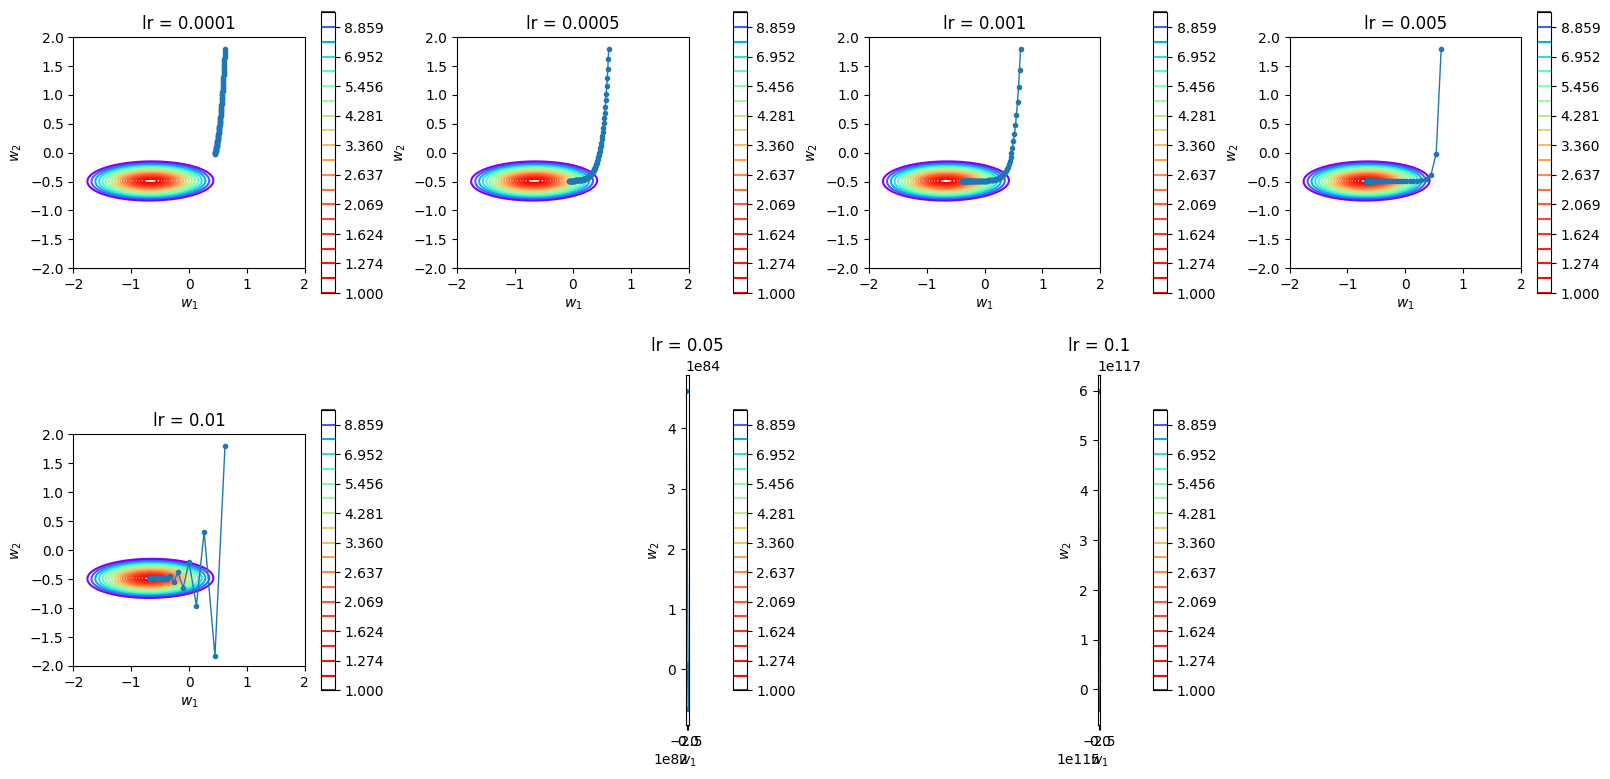

In [27]:

lrs = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 8),
    constrained_layout=True
)
axes_list = axes.flatten()

for ax, lr in zip(axes_list, lrs):
    w_cash = gradient_descent(w_init, X, y, loss, lr, 100)
    print(f"Learning Rate: {lr}")
    plt.sca(ax)
    plot_gd(w_cash, X, y, loss, ax = ax)
    ax.set_title(f"lr = {lr}", fontsize=12, pad=6)
    ax.set_xlabel(r"$w_1$", fontsize=10)
    ax.set_ylabel(r"$w_2$", fontsize=10)

for empty_ax in axes_list[7:]:
    empty_ax.axis("off")
plt.show()

### Вывод:
Нетрудно заметить, что при слишком маленьком lr на каждой итерации делается очень маленький шаг, что требует большого количества итераций для спуска к глобальному минимуму (при 100 итерациях модель даже близко не подбирается к цели). С увеличением lr повышается длина шага и соответственно сходимость модели к минимуму при меньшем количестве итераций (начиная с lr = 0.005, при lr = 0.001 все еще не доходит до минимума при 100 итерациях, но уже близко)

Однако при слишком большом шаге - lr >= 0.05 - модель в целом не приближается даже близко к минимуму из-за слишком большого шага

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [28]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """

    prom_w = w_init.copy()
    weights = [prom_w.copy()]

    for _ in range(n_iterations):
      batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
      X_batch = X[batch_indices]
      y_batch = y[batch_indices]
      grad = loss.calc_grad(X_batch, y_batch, prom_w)
      prom_w -= lr * grad
      weights.append(prom_w.copy())

    return weights

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

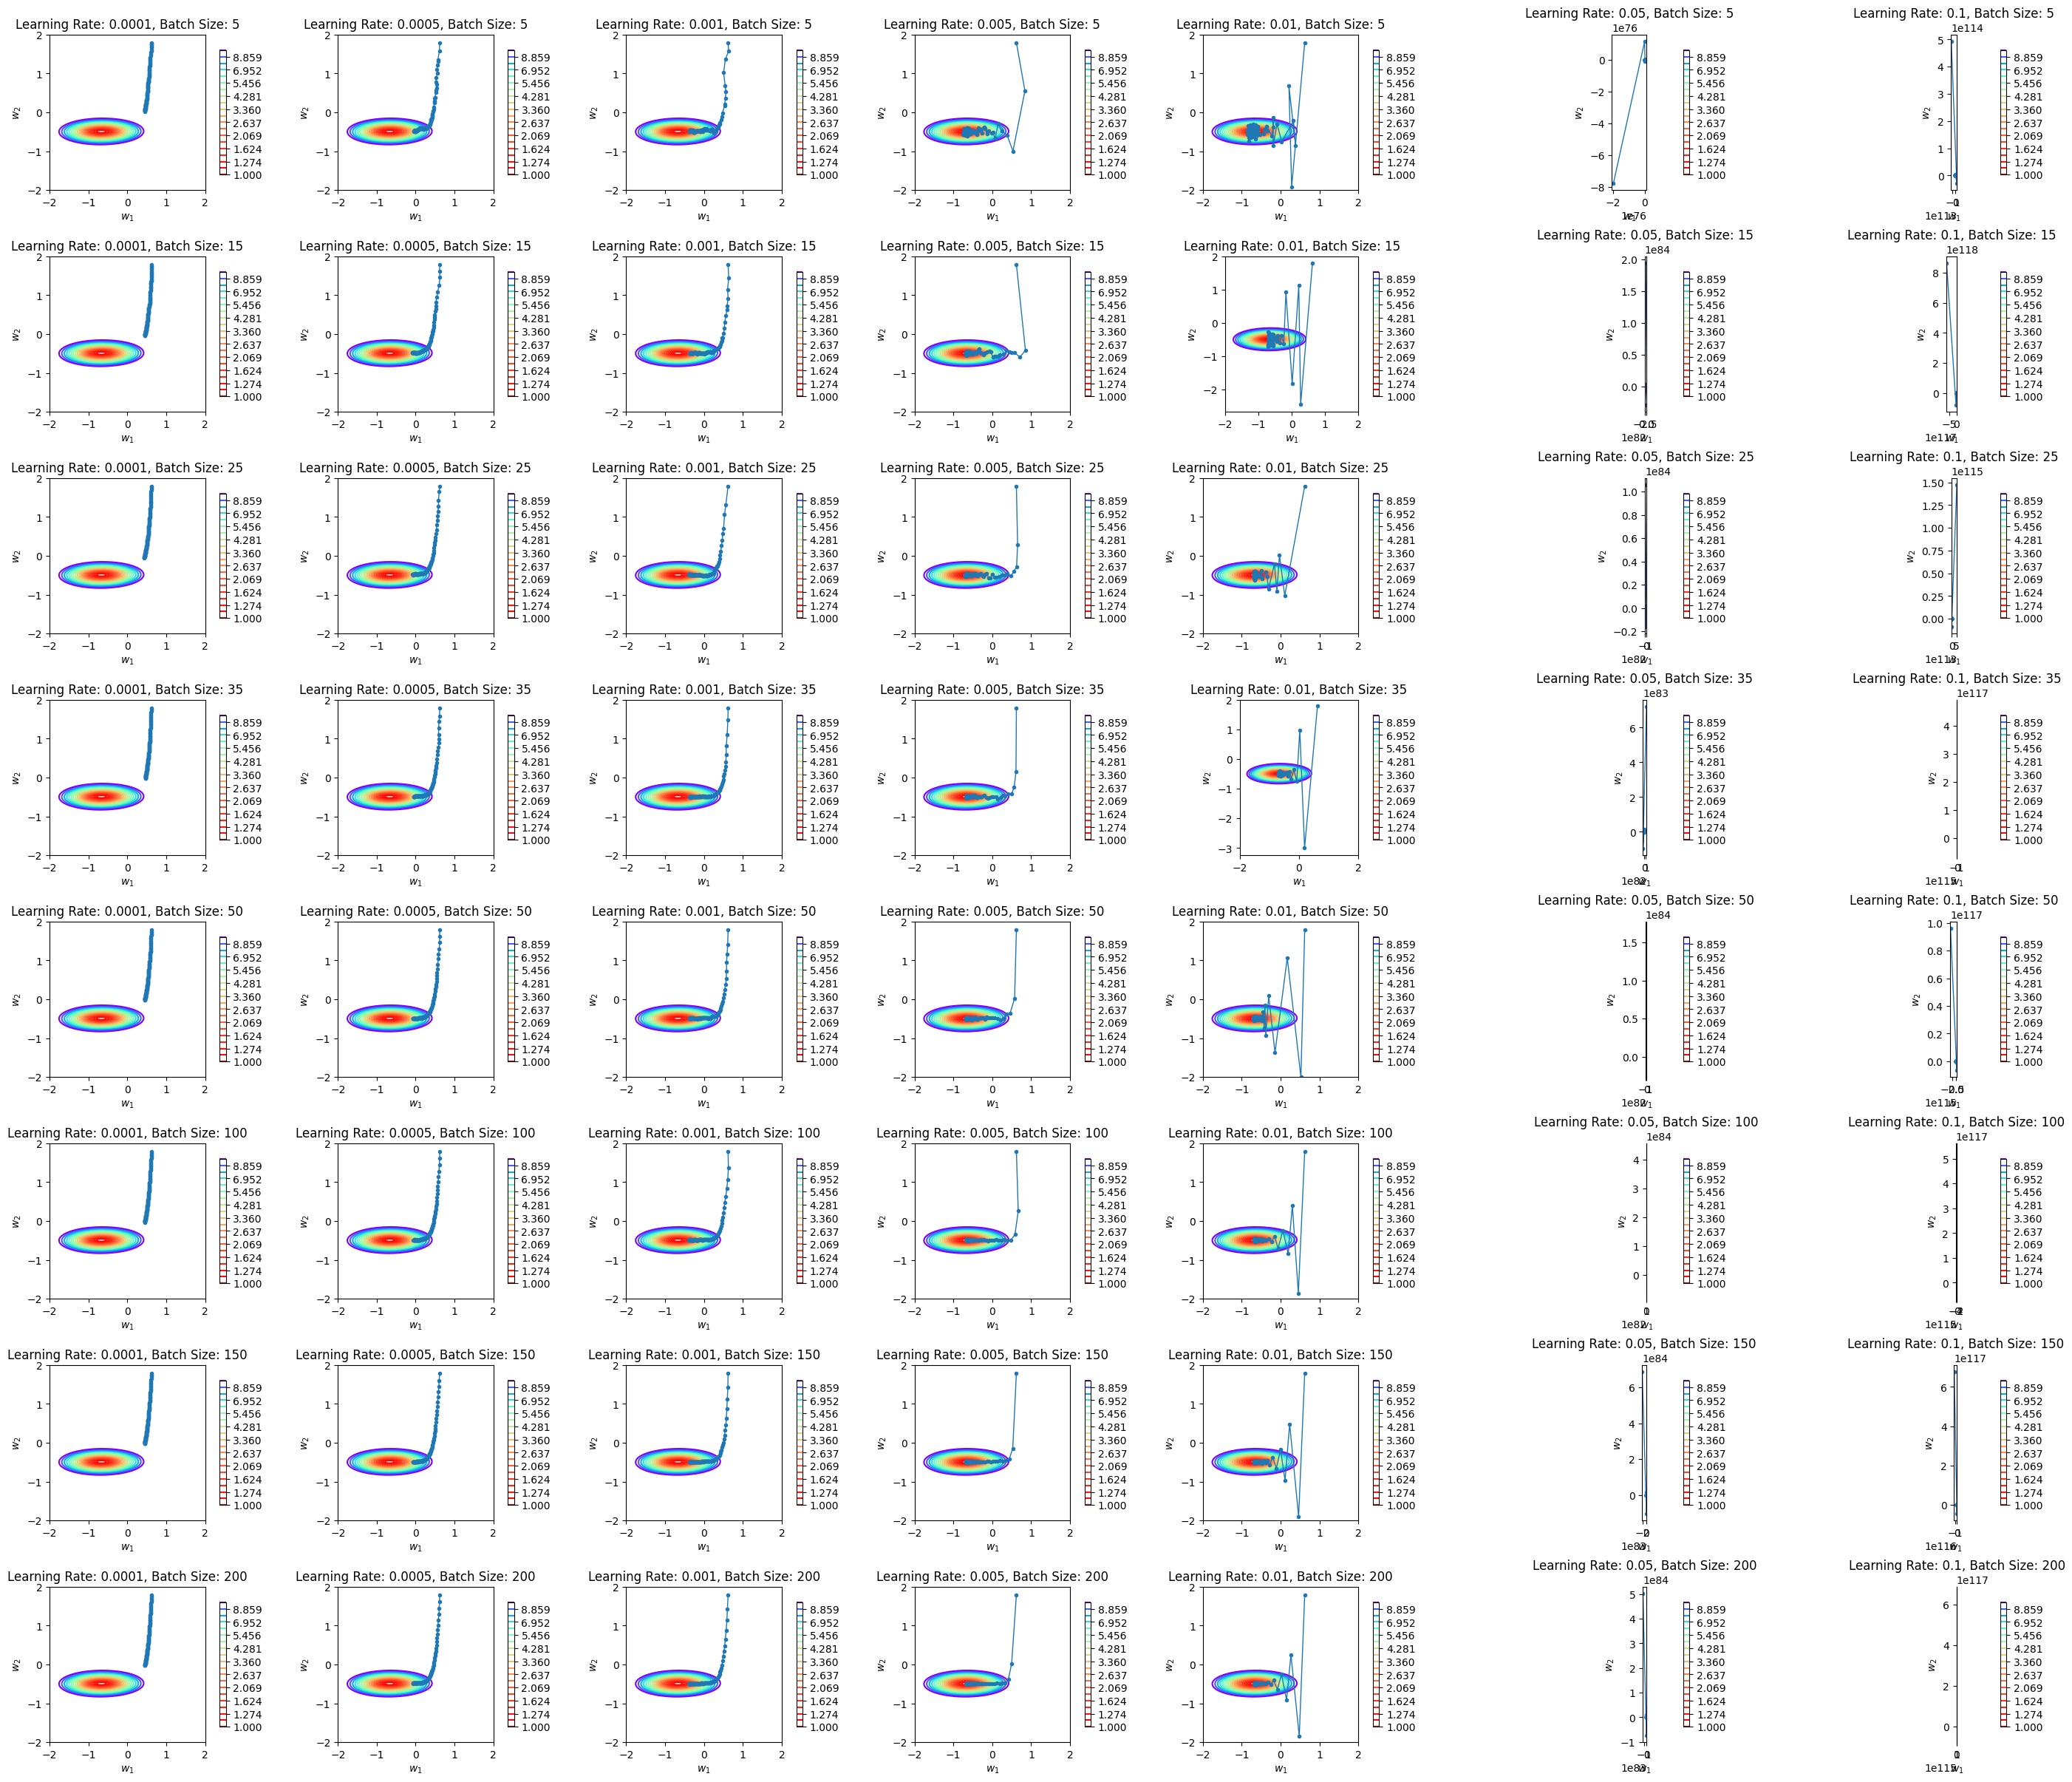

In [29]:
lrs = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
batch_sizes = [5, 15, 25, 35, 50, 100, 150, 200]

fig, axes = plt.subplots(
    8, 7,
    figsize=(28, 24),
    constrained_layout=True
)

axes_list = axes.flatten()

k = 0
for size in batch_sizes:
  for lr in lrs:
      w_cash = stochastic_gradient_descent(w_init, X, y, loss, lr, size, 100)
      plot_gd(w_cash, X, y, loss, ax = axes_list[k])
      axes_list[k].set_title(f"Learning Rate: {lr}, Batch Size: {size}", fontsize=12, pad=6)
      axes_list[k].set_xlabel(r"$w_1$", fontsize=10)
      axes_list[k].set_ylabel(r"$w_2$", fontsize=10)
      k+=1

plt.show()

### Вывод:
Как было замечено ранее, модель хорошо сходится при значениях lr 0.005 и 0,01.

При маленьких размерах батчей траектория спуска имеет сильный разброс, который выравнивается с увеличением размера выборки batch_size. Начиная с размера выборки 100 траектория спуска все меньше отличается с увеличениям batch_size: при batch_size>150 sgd уже почти не отличается от обычного градиентного спуска

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [30]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    prom_w = w_init.copy()
    weights = [prom_w]

    for i in range(n_iterations):
      batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
      X_batch = X[batch_indices]
      y_batch = y[batch_indices]
      grad = loss.calc_grad(X_batch, y_batch, prom_w)
      w = prom_w.copy()
      nt = lr*(1/(1+i))**p
      prom_w = prom_w - nt*grad
      weights.append(prom_w.copy())
      if np.linalg.norm(prom_w - w) < 10**(-6):
        break
    return weights

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

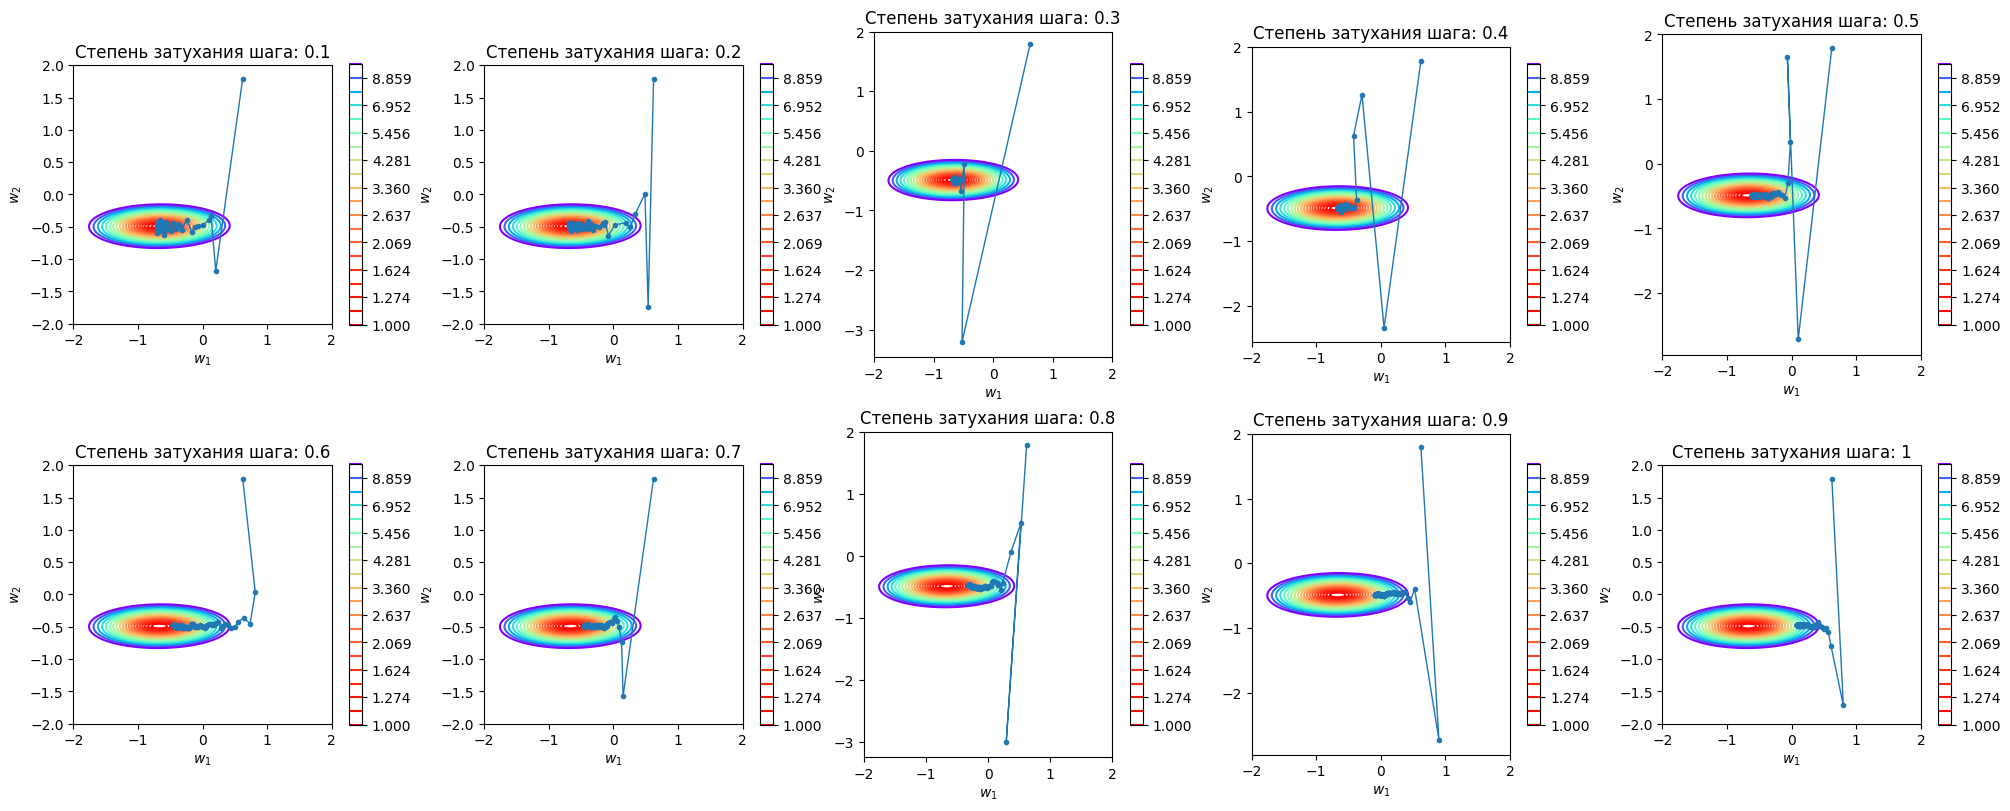

In [31]:
ps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)

axes_list = axes.flatten()

for i in range(len(ps)):
  w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, ps[i], 100)
  plot_gd(w_list, X, y, loss, ax = axes_list[i])
  axes_list[i].set_title(f"Степень затухания шага: {ps[i]}", fontsize=12, pad=6)
  axes_list[i].set_xlabel(r"$w_1$", fontsize=10)
  axes_list[i].set_ylabel(r"$w_2$", fontsize=10)

plt.show()

### Вывод:
По полученным визуализациям итераций шагов нетрудно заметить, что при слишком маленькой степени затухания шага модель делает слишком много "перепрыгиваний" минимума в его окрестности, тем самым сходясь дольше, чем можно было бы. При увеличении степени затухания эта проблема постепенно пропадает, однако начиная с p = 0.5 SGD не доходит до глобального минимума по причине слишком быстрого затухания шага, и чем больше p значения 0.5, тем дальше от минимума останавливается спуск. Это можно компенсировать количеством итераций, но для этого их понадобится значительно много, что повысит сложность и время спуска

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

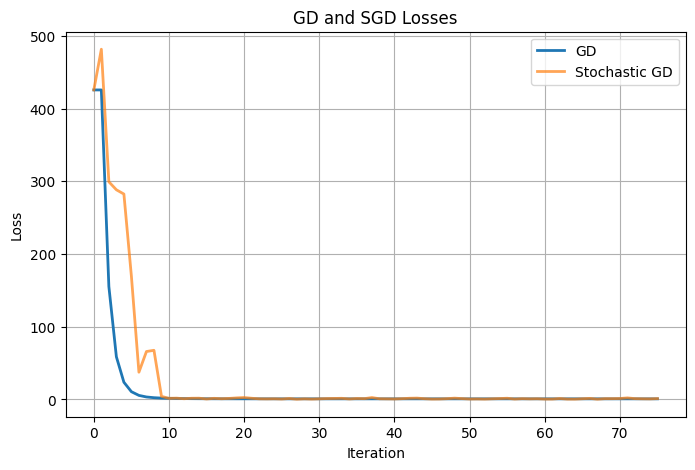

In [32]:
lr = 0.01
n_iterations = 100
batch_size = 10

w_gd = w_init.copy()
w_sgd = w_init.copy()

gd_losses = [loss.calc_loss(X, y, w_gd)]
sgd_losses = [loss.calc_loss(X, y, w_sgd)]

for i in range(n_iterations):
      # SGD
      batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
      X_batch = X[batch_indices]
      y_batch = y[batch_indices]
      grad = loss.calc_grad(X_batch, y_batch, w_sgd)
      loss_sgd = loss.calc_loss(X_batch, y_batch, w_sgd)
      sgd_losses.append(loss_sgd)
      nt = lr*(1/(1+i))**0.008
      w_sgd -= nt*grad



      # GD
      grad = loss.calc_grad(X, y, w_gd)
      loss_gd = loss.calc_loss(X, y, w_gd)
      w = w_gd.copy()
      w_gd -= lr*grad
      gd_losses.append(loss_gd)
      if np.linalg.norm(w_gd - w) < 10**(-6):
        break


plt.figure(figsize=(8, 5))
plt.plot(gd_losses, label="GD", linewidth=2)
plt.plot(sgd_losses, label="Stochastic GD", linewidth=2, alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("GD and SGD Losses")
plt.legend()
plt.grid(True)
plt.show()





### Вывод:
Как видно на построенном графике, обычный gd имеет более плавный убывающий график лосса, в то время как SGD выглядит в среднем убывающим, но с некоторыми колебаниями из-за случайности выбора батчей.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [96]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1, limit: int=1000) -> None:
        self.loss = loss
        self.lr = lr
        self.w = None
        self.limit = limit
    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        n_features = X.shape[1]
        self.w = np.zeros(n_features, dtype=np.float64)

        curr_loss = self.loss.calc_loss(X, y, self.w)
        self.losses = [curr_loss]

        for _ in range(self.limit):
          grad = self.loss.calc_grad(X, y, self.w)
          grad = np.asarray(grad, dtype=np.float64)
          w = self.w.copy()
          self.w -= self.lr*grad
          prom_loss = self.loss.calc_loss(X, y, self.w)
          self.losses.append(prom_loss)
          if np.linalg.norm(self.w - w) < 10**(-6):
            break
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X@self.w

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [97]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [98]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
import pandas as pd

X_raw = pd.read_csv(
    "/content/drive/MyDrive/cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [100]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [101]:
X_raw.apply({'dtypes', lambda x: x.isna().sum()}) #посмотрим какие есть пропуски и у каких типов признаков

,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
dtypes,int64,float64,object,object,object,object,object,object,object,float64,...,object,int64,object,float64,float64,float64,float64,float64,int64,int64
<lambda>,0,37,0,0,0,2,0,0,0,0,...,0,0,0,4,4,0,2,2,0,0


Пропуски у вещественных переменных заполним 0, а 6 признак типа object заменим согласно тем значениям, которые он принимает - он принимает числовые значения, записанные в формате строки (one, two, ...). Следовательно, пропуски есть смысл заполнить значением zero, а потом закодировать данный признак с помощью словаря перевода чисел из строки в числовую переменную.

In [102]:
X_raw[6]

,6
0,two
1,two
2,two
3,four
4,four
...,...
196,four
197,four
198,four
199,four


In [103]:
# заполним пропуски
for col in X_raw.columns:
    if X_raw[col].dtype == 'float64':
        X_raw[col] = X_raw[col].fillna(0.0)
    elif X_raw[col].dtype == 'int64':
        X_raw[col] = X_raw[col].fillna(0)
X_raw[6] = X_raw[6].fillna('zero')

nums = {'zero': 0, 'two': 2, 'four': 4}
X_raw[6] = X_raw[6].map(nums)  #переводим 6 признак из строчных чисел в числа

In [104]:
# отмасштабируем числовые признаки
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = X_raw.select_dtypes(include=['float64', 'int64']).columns
X_raw[num_cols] = scaler.fit_transform(X_raw[num_cols])

In [105]:
# Остальные переменные типа object закодируем с помощью One-Hot Encoder
X_raw = pd.get_dummies(X_raw, columns=X_raw.select_dtypes(include=['object']).columns)


In [106]:
# Разделим датасет на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

X_test, X_train, y_test, y_train = train_test_split(X_raw, y, test_size=0.3, random_state=28)

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [107]:
linear_regression.fit(X_train, y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [108]:
from sklearn.metrics import mean_squared_error

y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

mses = pd.DataFrame({'train': [mse_train], 'test': [mse_test]})
mses

,train,test
0,1.020668e+06,1.761066e+07


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [109]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        X = np.asarray(X)
        y = np.asarray(y)
        w_norm = np.linalg.norm(w[:-1], ord=2) ** 2
        loss = np.mean((X@w - y)**2) + self.coef*w_norm

        return loss
        # -- YOUR CODE HERE -- (´｡• ᵕ •｡`)
        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        X = np.asarray(X)
        y = np.asarray(y)

        grad = 2*X.T@(X@w - y)/ X.shape[0]
        grad[:-1] += 2*self.coef*w[:-1]
        return grad
        # -- YOUR CODE HERE -- (￢_￢)
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [110]:
linear_regression = LinearRegression(MSEL2Loss(0.4))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [111]:
linear_regression.fit(X_train, y_train)

y_train_pred_l2 = linear_regression.predict(X_train)
y_test_pred_l2 = linear_regression.predict(X_test)

mse_train_l2 = mean_squared_error(y_train, y_train_pred_l2)
mse_test_l2 = mean_squared_error(y_test, y_test_pred_l2)

mse_l2 = pd.DataFrame({'train': [mse_train_l2], 'test': [mse_test_l2]})
mses_compare = pd.concat([mses, mse_l2], ignore_index=True)
mses_compare

,train,test
0,1.020668e+06,1.761066e+07
1,7.305432e+06,1.189237e+07


При  сравнении значений ошибок на тестовой и обучающей выборках для линейной регрессии без регуляризации и с L2-регуляризацией, можно отметить, что потери на обучении стали меньше, что говорит о том, что модель не переобучается так сильно, как без регуляризации (где ошибка на train ~ 1.9 млн, а на test ~ 16.3 млн)
После регуляризации при коэффициенте 0.4 ошибка на train ~ 7.3 млн, ошибка на test ~ 12.6 млн

Потери на тесте немного уменьшились, но всё ещё высокие

### Посмотрим на размер ошибок на тестовой и обучающей выборках в зависимости от коэффициента регуляризации:

<ipython-input-112-ca847f5c2599>:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mses_per_lambda = pd.concat([mses_per_lambda, mse_l2], ignore_index=True)


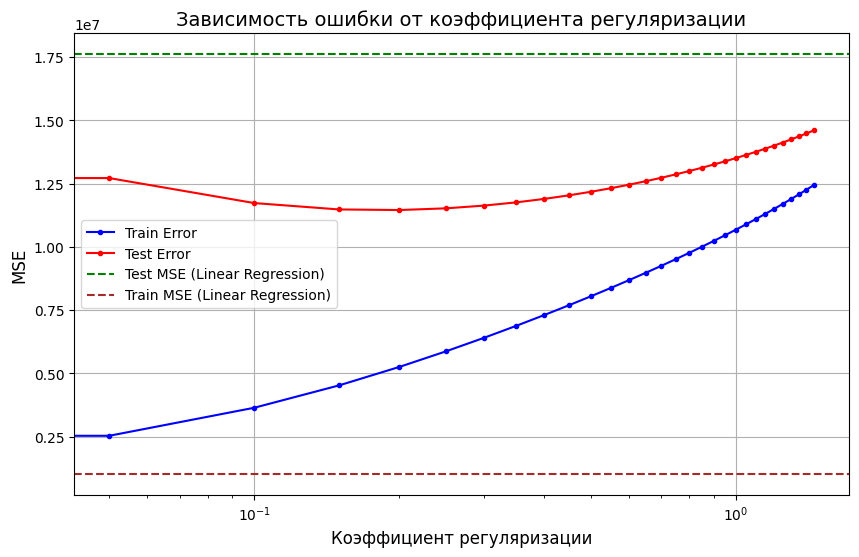

In [112]:
lam = [0.01* x for x in range(0, 150, 5)]
mses_per_lambda = pd.DataFrame(columns = ['coef', 'train', 'test'])
for l in lam:
  linear_regression = LinearRegression(MSEL2Loss(l))
  linear_regression.fit(X_train, y_train)
  y_train_pred_l2 = linear_regression.predict(X_train)
  y_test_pred_l2 = linear_regression.predict(X_test)

  mse_train_l2 = mean_squared_error(y_train, y_train_pred_l2)
  mse_test_l2 = mean_squared_error(y_test, y_test_pred_l2)

  mse_l2 = pd.DataFrame({'coef': [l], 'train': [mse_train_l2], 'test': [mse_test_l2]})
  mses_per_lambda = pd.concat([mses_per_lambda, mse_l2], ignore_index=True)

plt.figure(figsize=(10, 6))

plt.plot(mses_per_lambda['coef'], mses_per_lambda['train'], label='Train Error', color='blue', marker='.')
plt.plot(mses_per_lambda['coef'], mses_per_lambda['test'], label='Test Error', color='red', marker='.')

plt.axhline(y=mse_test, color='green', linestyle='--', label='Test MSE (Linear Regression)')
plt.axhline(y=mse_train, color='brown', linestyle='--', label='Train MSE (Linear Regression)')

plt.xlabel('Коэффициент регуляризации', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Зависимость ошибки от коэффициента регуляризации', fontsize=14)
plt.xscale('log')
plt.legend()

plt.grid(True)
plt.show()


В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [113]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        X = np.asarray(X)
        y = np.asarray(y)

        err = np.abs(X@w - y)
        loss = np.mean(np.where(err<self.eps, err**2/2, self.eps*(err - self.eps/2)))
        return loss




    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        X = np.asarray(X)
        y = np.asarray(y)

        err = X@w - y
        grad = X.T@np.where(np.abs(err)<self.eps, err, self.eps*(np.sign(err)))/X.shape[0]
        return grad

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [114]:
linear_regression_Huber = LinearRegression(HuberLoss(50))

linear_regression_Huber.fit(X_train, y_train)

y_train_pred_huber = linear_regression_Huber.predict(X_train)
y_test_pred_huber = linear_regression_Huber.predict(X_test)

mse_train_huber = mean_squared_error(y_train, y_train_pred_huber)
mse_test_huber = mean_squared_error(y_test, y_test_pred_huber)

mse_huber = pd.DataFrame({'train': [mse_train_huber], 'test': [mse_test_huber]})
mses_compare_huber = pd.concat([mses, mse_huber], ignore_index=True)
mses_compare_huber

,train,test
0,1.020668e+06,1.761066e+07
1,2.274651e+07,2.834006e+07


<ipython-input-115-9a6d3a581d97>:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mses_per_eps = pd.concat([mses_per_eps, mse_huber], ignore_index=True)


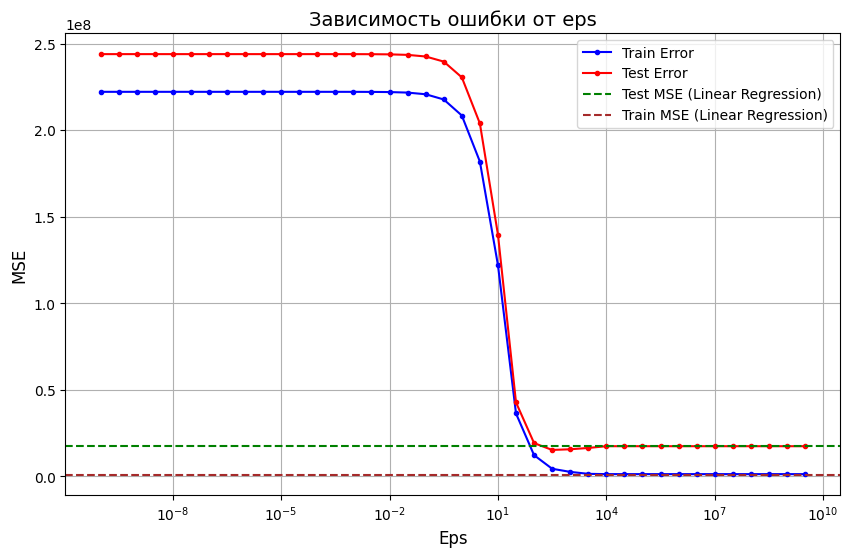

In [115]:
epsilons = [10**(x/2) for x in range(-20, 20)]
mses_per_eps = pd.DataFrame(columns = ['eps', 'train', 'test'])
for eps in epsilons:
  linear_regression_Huber = LinearRegression(HuberLoss(eps))
  linear_regression_Huber.fit(X_train, y_train)

  y_train_pred_huber = linear_regression_Huber.predict(X_train)
  y_test_pred_huber = linear_regression_Huber.predict(X_test)

  mse_train_huber = mean_squared_error(y_train, y_train_pred_huber)
  mse_test_huber = mean_squared_error(y_test, y_test_pred_huber)

  mse_huber = pd.DataFrame({'eps': [eps], 'train': [mse_train_huber], 'test': [mse_test_huber]})
  mses_per_eps = pd.concat([mses_per_eps, mse_huber], ignore_index=True)

plt.figure(figsize=(10, 6))

plt.plot(mses_per_eps['eps'], mses_per_eps['train'], label='Train Error', color='blue', marker='.')
plt.plot(mses_per_eps['eps'], mses_per_eps['test'], label='Test Error', color='red', marker='.')

plt.axhline(y=mse_test, color='green', linestyle='--', label='Test MSE (Linear Regression)')
plt.axhline(y=mse_train, color='brown', linestyle='--', label='Train MSE (Linear Regression)')

plt.xlabel('Eps', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Зависимость ошибки от eps', fontsize=14)
plt.legend()
plt.xscale('log')
plt.grid(True)
plt.show()

Huber Loss оказалась в большинстве сильно хуже обычной Линейной регрессии, что скорее всего связано с отсутствием выбросов как таковых, из-за чего Huber Loss принимает за выбросы обычные значения, которые важны.

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

In [116]:
# -- YOUR MEME HERE -- ╰( ͡° ͜ʖ ͡° )つ▬▬ι═══════  bzzzzzzzzzz

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [117]:
class LinearRegressionOtzhig:
    def __init__(self, loss: BaseLoss, T_start: float =1.0, alpha: float=0.9, limit: int=1000, t_criteria: int=3) -> None:
        self.loss = loss
        self.w = None
        self.T_start = T_start
        self.alpha = alpha
        self.limit = limit
        self.t_criteria = t_criteria
    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)

        n_features = X.shape[1]
        self.w = np.random.randn(n_features)

        T = self.T_start
        curr_loss = self.loss.calc_loss(X, y, self.w)
        self.losses = [curr_loss]

        for i in range(self.limit):
          new_w = self.w + np.random.standard_t(self.t_criteria, size=self.w.shape)
          new_loss = self.loss.calc_loss(X, y, new_w)

          if new_loss - curr_loss < 0 or np.random.rand() < np.exp((curr_loss - new_loss) / T):
            self.w = new_w
            curr_loss = new_loss

          self.losses.append(curr_loss)
          T *= self.alpha

    def predict(self, X: np.ndarray) -> np.ndarray:
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        return X@self.w

In [154]:
loss = MSELoss()
otzhig = LinearRegressionOtzhig(loss,T_start = 100, alpha = 0.99, t_criteria = 1, limit = 3000)

otzhig.fit(X_train, y_train)
otzhig_losses = otzhig.losses
y_predicted_test_otzhig = otzhig.predict(X_test)
y_predicted_train_otzhig = otzhig.predict(X_train)

mse_train_otzhig = mean_squared_error(y_train, y_predicted_train_otzhig)
mse_test_otzhig = mean_squared_error(y_test, y_predicted_test_otzhig)
mses_otzhig = pd.DataFrame({'Loss': ['Otzhig'],'train': [mse_train_otzhig], 'test': [mse_test_otzhig]})


linreg = LinearRegression(loss, limit = 3000)

linreg.fit(X_train, y_train)
linreg_losses = linreg.losses
y_predicted_test_linreg = linreg.predict(X_test)
y_predicted_train_linreg = linreg.predict(X_train)

mse_train_linreg = mean_squared_error(y_train, y_predicted_train_linreg)
mse_test_linreg = mean_squared_error(y_test, y_predicted_test_linreg)
mses_linreg = pd.DataFrame({'Loss': ['GD'],'train': [mse_train_linreg], 'test': [mse_test_linreg]})

compare = pd.concat([mses_linreg, mses_otzhig], ignore_index=True)
compare







,Loss,train,test
0,GD,6.434198e+05,2.113581e+07
1,Otzhig,2.271552e+06,2.419069e+07


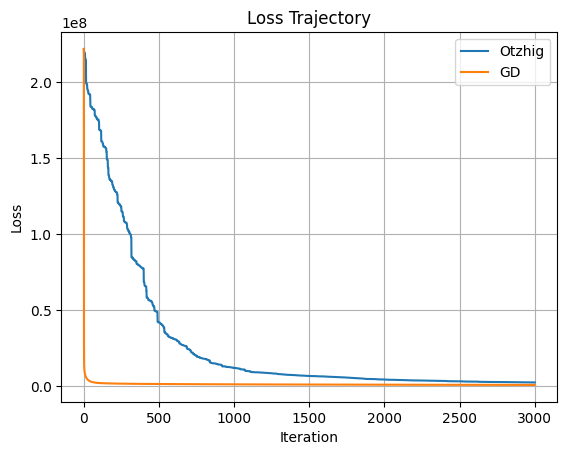

In [155]:

plt.plot(otzhig_losses, label='Otzhig')
plt.plot(linreg_losses, label='GD')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Trajectory")
plt.legend()
plt.grid(True)
plt.show()

Поэксперементировав с количеством степеней свободы в t распределении, показателем alpha и количеством итераций можно сказать, что чем больше количество степеней свободы, тем дольше имитация отжига будет сходиться, то есть понадобится больше итераций.

По графикам видно, что в целом градиентный спуск сходится к минимуму быстрее чем имитация отжига.